In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from ydata_profiling import ProfileReport
import pickle
import random
import itertools

pd.options.display.max_columns = None
pd.options.display.max_colwidth = 50

data_folder = "../data/"
images_folder = "../data/images/"
pipelines_folder = "../pipelines/"
df_total = pd.read_csv(os.path.join(data_folder, 'items_phase_1.csv'))
df_train = pd.read_csv(os.path.join(data_folder, 'items_train.csv'))
df_task_1 = pd.read_csv(os.path.join(data_folder, 'task_1.csv'))

# Notebook `items_phase_1.csv`

In [2]:
# profile = ProfileReport(df_total, title="items_phase_1", explorative=True)
# profile.to_notebook_iframe()

In [3]:
print("Length of dataset:", len(df_total))

Length of dataset: 199835


In [4]:
df_total.sample(2)

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo
178015,1115023,129.34,6446,[],NaN,Biela dámska ľahká vzorovaná bunda Guess Vera,Model: Vera\nFarba: biela\nVzor: s potlačou\nT...,sk
158224,257264,49.95,"6445,6455",['1'],NaN,Sneakersy Pepe Jeans,Pepe Jeans Sneakersy London W Part PLS31465 Écru,sk


## Key takeaway
- missingy se musi resit u:
    - description (3%)
    - brandEditionTagId (99.8%) - to je asi target?
    - colorTagIdsString (3.1%)
---
# Notebook `task_1.csv`
- kazdy radek je jedna skupina se sloupci item - item4(to jsou id do items_phase_1.csv - itemId)
- Kazdy 

In [5]:
print("Length of dataset:", len(df_task_1))

Length of dataset: 15000


In [6]:
# profile = ProfileReport(df_task_1, title="task_1", explorative=True)
# profile.to_notebook_iframe()

In [7]:
df_task_1.head()

,item1,item2,item3,item4,item5
0,130622,292253,463442,483968,1253745
1,82627,388496,553738,638400,884327
2,46130,333489,644448,848154,1178149
3,150796,248537,742067,1206230,1280786
4,76610,196894,345145,620255,932761


---
# Dataset `items_train.csv`
- obsahuje toho min, vim ze ma stejny hodnoty v departmentIds


In [8]:
print("Total records:", len(df_train))
print("Total null values:\n", df_train.isnull().sum())

Total records: 928234
Total null values:
 itemId                    0
price                     0
colorTagIdsString     27834
departmentIds             0
brandEditionTagId    925518
title                     0
description           35473
geo                       0
label                     0
dtype: int64


In [9]:
df_train.sample(2)

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo,label
837235,915902,7.14,6446,[],NaN,Eurofirany Unisex's Pillow Case 404761,Description:\nWashing instructions: 30°C Hand ...,sk,172844
613645,1172601,36.95,783,['11'],NaN,Vyriškas Diržas Barbour,Barbour Vyriškas Diržas Contrast MAC0351OL51 Ruda,lt,46975


In [10]:
# profile = ProfileReport(df_train, title="task_1", explorative=True)
# profile.to_notebook_iframe()


--- 
## Ukazka obrazku + kontrola zda mame vsechny

=== Ukazka ===
itemId                                        225269
price                                          85.95
colorTagIdsString                               6460
departmentIds                                  ['1']
brandEditionTagId                                NaN
title                                   Šľapky Guess
description          Šľapky Guess FLJRLL LEA19 Hnedá
geo                                               sk
label                                          38980
Name: 79, dtype: object



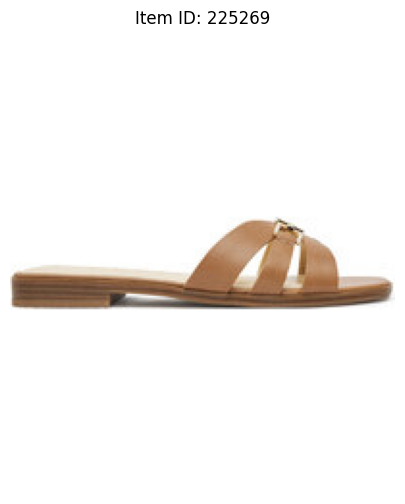

In [11]:
import os
import matplotlib.pyplot as plt
from PIL import Image

first_row = df_train.iloc[79] 
item_id = first_row['itemId']

print("=== Ukazka ===")
print(first_row)
print("===============================\n")

img_path = os.path.join(images_folder, f"{item_id}.jpg")

img = Image.open(img_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f"Item ID: {item_id}")
plt.show()

In [12]:
import os
import pandas as pd

def find_missing_images(df, images_folder, item_col='itemId'):
    print("🔍 Analyzuji dataset a složku s obrázky...")
    
    expected_ids = set(df[item_col].astype(str))
    print(f"📊 Tabulka vyžaduje: {len(expected_ids)} unikátních obrázků.")
    
    try:
        available_files = [f[:-4] for f in os.listdir(images_folder) if f.endswith('.jpg')]
        available_ids = set(available_files)
        print(f"📂 Na disku nalezeno: {len(available_ids)} .jpg souborů.")
    except FileNotFoundError:
        print(f"❌ Chyba: Složka '{images_folder}' neexistuje!")
        return []

    missing_ids = expected_ids - available_ids
    
    if len(missing_ids) == 0:
        print("🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.")
    else:
        print(f"⚠️ POZOR: Chybí přesně {len(missing_ids)} obrázků!")
        print(f"Ukázka chybějících ID: {list(missing_ids)[:5]}")
        
    return list(missing_ids)

chybejici_obrazky = find_missing_images(df_total, images_folder)
chybejici_obrazky = find_missing_images(df_train, images_folder)

🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 199835 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.
🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.


---
# Vycisteni dat 
- prevod na spolecnou menu 
- normalizace meny v danem geo uzemi
- doplneni null hodnot
- null ve sloupci `colorTagIdString` muzu nahradit 0 
- `colorTagIdString` a `departmentIds` je potreba roztrhnout - obsahuji vice hodnot oddelenych carkou

## Tvorba preprocessing pipeline

In [13]:
df_total[df_total["brandEditionTagId"] == 0]

,itemId,price,colorTagIdsString,departmentIds,brandEditionTagId,title,description,geo


In [14]:
df_train.columns

Index(['itemId', 'price', 'colorTagIdsString', 'departmentIds',
       'brandEditionTagId', 'title', 'description', 'geo', 'label'],
      dtype='object')

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from PriceGeoTransformer import PriceGeoTransformer
from DepartmentIdsTransformer import DepartmentIdsCleaner
import numpy as np


input_unknown_cols = ["description","title"]
input_unknown_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="Unknown")),
])



# Pro textové IDčka (barvy) dáme prázdný string
imput_empty_string_cols = ['colorTagIdsString']
input_empty_string_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value="")),
])

imput_zero_cols = ["brandEditionTagId"]
input_zero_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
])


# prevadi na stejny format jako jsou barvy - cisla oddelena carkou 
department_features = ['departmentIds']
department_transformer = Pipeline(steps=[
    ('DepartmentIdsCleaner', DepartmentIdsCleaner())
])

# impute missing geo and convert back to pandas
imputer_step = ColumnTransformer(
    transformers=[
        ('geo_imp', SimpleImputer(strategy='constant', fill_value='<UNK>'), ['geo']),
        ('price_imp', SimpleImputer(strategy='median'), ['price'])
    ], 
    remainder='passthrough',
    verbose_feature_names_out=False 
).set_output(transform="pandas")

categorical_features = ['geo',"price"]
categorical_transformer = Pipeline(steps=[
    ("imputer", imputer_step),
    ('PriceGeoTransformer', PriceGeoTransformer())
])


# Combine preprocessing for numeric and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('zero', input_zero_transformer, imput_zero_cols),
        ('unknown', input_unknown_transformer, input_unknown_cols),
        ('geo', categorical_transformer, categorical_features),
        ('department', department_transformer, department_features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform="pandas")



pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

X_train = df_train.drop(columns=['label'])
y_train = df_train['label']

X_train_transformed = pipeline.fit_transform(X_train)
df_train_transformed = X_train_transformed.copy()
df_train_transformed['label'] = y_train.values
df_total_transformed = pipeline.transform(df_total)

In [16]:
pickle.dump(pipeline, open(os.path.join(pipelines_folder, 'preprocessing_pipeline.pkl'), 'wb'))

In [17]:
# find_missing_images(df_total_transformed, images_folder)
find_missing_images(df_train_transformed, images_folder)

🔍 Analyzuji dataset a složku s obrázky...
📊 Tabulka vyžaduje: 928234 unikátních obrázků.
📂 Na disku nalezeno: 1325907 .jpg souborů.
🎉 Perfektní! Úplně každý záznam v tabulce má svůj fyzický obrázek.


[]

## Příprava pro PyTorch dataset - Vocabulary pro transformaci kategorií
- PyTorch bude použit na vytvoření embeddingů sloupců s více kategorijema a na kategorické sloupce
- PyTorch umí totiž lépe tvořit řídké matice
- Vytvoříme si mappingy pro jednotlivé kategorie...

In [18]:
from GlamiDatasetVocabulary import GlamiVocabularyManager
vocab_manager = GlamiVocabularyManager() # vytvori vsechny potrebne mappingy kategorii do ciselnych hodnot
vocab_manager.fit(df_total_transformed)
vocab_manager.save()

## Tvorba embeddingů obrázků

In [19]:
import torch
from transformers import CLIPProcessor, CLIPVisionModel
from PIL import Image
import os
from tqdm import tqdm # Pro hezký progress bar

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Běžíme na MPS!")
else:
    device = torch.device("cpu")
    print("⚠️ Běžíme na CPU.")

🚀 Běžíme na MPS!


In [20]:
def create_and_save_clip_embeddings(image_dir, item_ids, save_path="clip_embeddings.pt", batch_size=128):
    item_ids = list(item_ids)
    
    model_id = "openai/clip-vit-base-patch32"
    print(f"Načítám model {model_id}...")
    processor = CLIPProcessor.from_pretrained(model_id)
    model = CLIPVisionModel.from_pretrained(model_id).to(device)
    model.eval() # Přepneme do módu vyhodnocování

    embeddings_dict = {}
    valid_ids = []
    images_to_process = []

    print("Připravuji obrázky...")
    
    # processing images
    for i in tqdm(range(0, len(item_ids), batch_size)):
        batch_ids = item_ids[i:i + batch_size]
        batch_images = []
        batch_valid_ids = []

        # Načteme obrázky v dávce
        for item_id in batch_ids:
            img_path = os.path.join(image_dir, f"{item_id}.jpg")
            try:
                img = Image.open(img_path).convert("RGB")
                batch_images.append(img)
                batch_valid_ids.append(str(item_id))
            except Exception:
                print("Missing image for item_id:", item_id)


        if not batch_images:
            continue

        # 4. Provedení samotné extrakce na čipu
        with torch.no_grad(): # Šetří paměť, nechceme počítat gradienty
            inputs = processor(images=batch_images, return_tensors="pt").to(device)
            outputs = model(**inputs)
            image_embeds = outputs.pooler_output 

            # 5. Uložení do slovníku (přesuneme zpět na CPU, ať neplníme GPU paměť)
            image_embeds = image_embeds.cpu()
            for idx, i_id in enumerate(batch_valid_ids):
                embeddings_dict[i_id] = image_embeds[idx]

    print(f"Ukládám {len(embeddings_dict)} embeddingů do {save_path}...")
    torch.save(embeddings_dict, save_path)
    print("Hotovo! 🎉")
    
    return embeddings_dict

In [21]:
import os
import torch

os.environ["HF_HUB_OFFLINE"] = "1"

print("Připravuji CLIP embeddingy...")
item_ids_list = df_train_transformed['itemId'].unique().tolist()
embeddings_path = "clip_embeddings.pt"

# Chytrá kontrola: nebudeme to počítat znovu, pokud už to máme!
if os.path.exists(embeddings_path):
    print("Načítám hotové embeddingy z disku (blesková akce)...")
    clip_embeddings_dict = torch.load(embeddings_path)
else:
    print("Soubor nenalezen. Žhavím Apple M4 Pro a jdu počítat z obrázků...")
    # Tady zavoláme tu funkci z minula!
    clip_embeddings_dict = create_and_save_clip_embeddings(
        image_dir=images_folder, 
        item_ids=item_ids_list, 
        save_path=embeddings_path, 
        batch_size=128 # M4 Pro zvládne velké batche s přehledem
    )

print(f"Máme {len(clip_embeddings_dict)} vektorů obrázků!")

Připravuji CLIP embeddingy...
Načítám hotové embeddingy z disku (blesková akce)...
Máme 928234 vektorů obrázků!


## PyTorch Dataset


--- 


## Tvorba siamese datasetu
- dataset obsahuje páry z originálního datasetu teré mají jako label 1 pokud mají stejné labely uvitř páru, jinak 0
- create_balanced_pairs jich vytvori tolik aby byly vyvazene labely 